# Import data and Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import matplotlib.cm as cm # colormaps
import matplotlib.pyplot as plt
# plt.style.use("dark_background")
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
train_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [4]:
test_df = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")
test_df.head()                      

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


# Data Visualization

In [5]:
import matplotlib

available_colors = list(matplotlib.colors.cnames.keys())
import pandas as pd

color_df = pd.DataFrame({'index': range(len(available_colors)), 'color_name': available_colors})
color_df.head(20)

,index,color_name
0,0,aliceblue
1,1,antiquewhite
2,2,aqua
3,3,aquamarine
4,4,azure
5,5,beige
6,6,bisque
7,7,black
8,8,blanchedalmond
9,9,blue


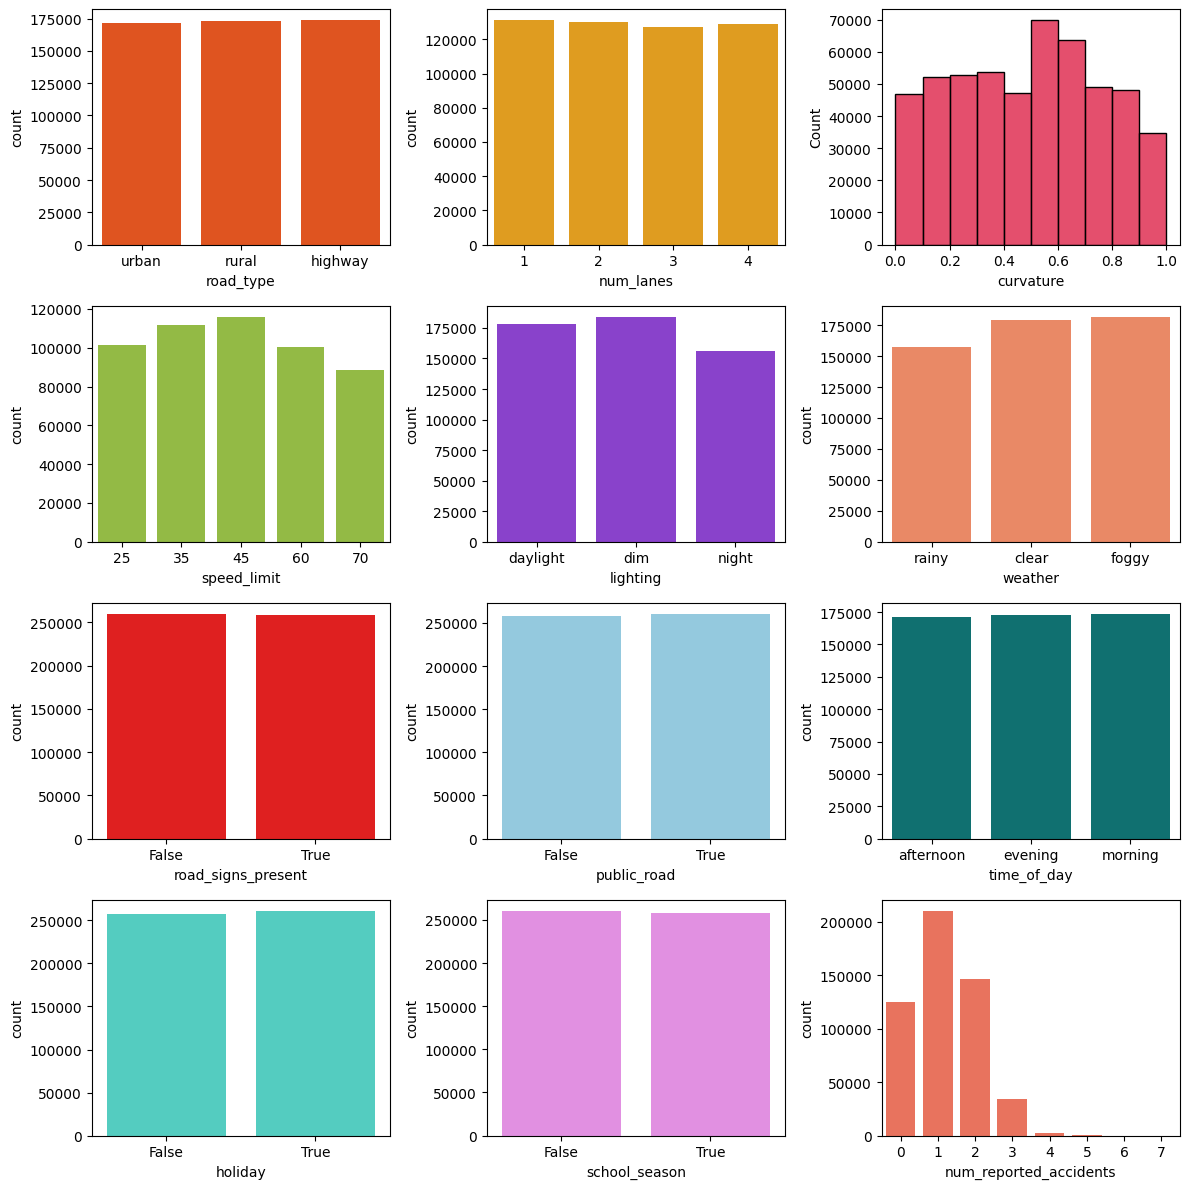

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))

sns.countplot(data=train_df, x = 'road_type' ,ax=axes[0, 0], color='orangered')
sns.countplot(data=train_df, x = 'num_lanes' ,ax=axes[0, 1], color='orange')
sns.histplot(train_df['curvature'], ax=axes[0, 2], color='crimson', binwidth=0.1)
sns.countplot(data=train_df, x = 'speed_limit' ,ax=axes[1, 0], color='yellowgreen')
sns.countplot(data=train_df, x = 'lighting' ,ax=axes[1, 1], color=available_colors[10])
sns.countplot(data=train_df, x = 'weather' ,ax=axes[1, 2], color=available_colors[16])
sns.countplot(data=train_df, x = 'road_signs_present' ,ax=axes[2, 0], color='red')
sns.countplot(data=train_df, x = 'public_road' ,ax=axes[2, 1], color=available_colors[130])
sns.countplot(data=train_df, x = 'time_of_day' ,ax=axes[2, 2], color=available_colors[138])
sns.countplot(data=train_df, x = 'holiday' ,ax=axes[3, 0], color=available_colors[141])
sns.countplot(data=train_df, x = 'school_season' ,ax=axes[3, 1], color=available_colors[142])
sns.countplot(data=train_df, x = 'num_reported_accidents' ,ax=axes[3, 2], color=available_colors[140])

# # log scale for income
# marketing['Log_Income'] = np.log(marketing['Income'])
# sns.boxplot(data=marketing, x = 'Log_Income' ,ax=axes[1, 1], color='yellowgreen')
# marketing.drop('Log_Income', axis=1, inplace=True)
plt.tight_layout()
plt.show()

<Axes: xlabel='accident_risk', ylabel='Count'>

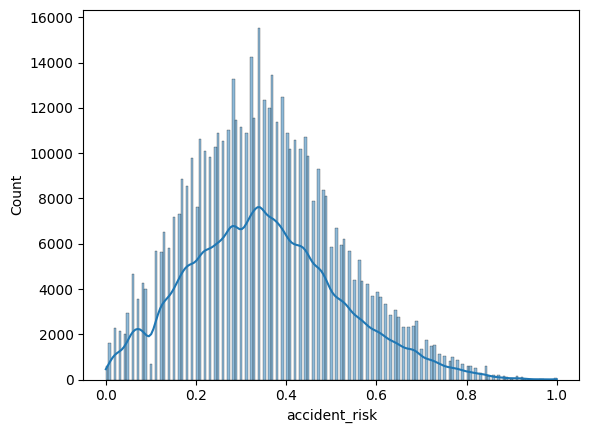

In [7]:
sns.histplot(train_df['accident_risk'], kde=True)

In [8]:
train_df.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [9]:
test_df.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents
count,172585.000000,172585.000000,172585.000000,172585.000000,172585.000000
mean,604046.000000,2.494046,0.487263,46.102761,1.186059
std,49821.142441,1.119148,0.272343,15.787077,0.897161
min,517754.000000,1.000000,0.000000,25.000000,0.000000
25%,560900.000000,1.000000,0.260000,35.000000,1.000000
50%,604046.000000,2.000000,0.510000,45.000000,1.000000
75%,647192.000000,3.000000,0.710000,60.000000,2.000000
max,690338.000000,4.000000,1.000000,70.000000,7.000000


# Modelling 1

## Data Preprocessing

## Model training

In [10]:
# Drop irrelevant columns
train_df_new = train_df.drop('id', axis=1)

# Define features and target
X = train_df_new.drop('accident_risk', axis=1)
y = train_df_new['accident_risk']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [11]:
# 🔹 Preprocessing pipelines for both types of data
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 🔹 Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 🔹 Build final pipeline with model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 🔹 Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Train model
model.fit(X_train, y_train)

# 🔹 Predictions
y_pred = model.predict(X_test)

# 🔹 Evaluate model
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.8533111680474196
MAE: 0.049340322340237074
RMSE: 0.06364275704518094


In [12]:
# =============================
#  Predict on Test Data
# =============================
test_df_new = test_df.drop('id', axis=1)

test_predictions = model.predict(test_df_new)

# Create a DataFrame for output
output = pd.DataFrame({
    'id': test_df['id'],            # or use test_df['id'] if exists
    'accident_risk': test_predictions
})

# Save predictions
output.to_csv('/kaggle/working/predictions_modelling1.csv', index=False)

print("✅ File saved successfully at: /kaggle/working/predictions_modelling1.csv")

✅ File saved successfully at: /kaggle/working/predictions_modelling1.csv


## Saving the model

In [13]:
import joblib

# Save model to a .pkl file
joblib.dump(model, '/kaggle/working/predictions_modelling1.pkl', compress=7)

print("✅ Model saved as 'predictions_modelling1.pkl' in /kaggle/working/")


✅ Model saved as 'predictions_modelling1.pkl' in /kaggle/working/


In [14]:
rf_model = model.named_steps['regressor']

joblib.dump(rf_model, "new_predictions_model1.pkl", compress=3)
print("✅ Model saved as 'new_predictions_model1.pkl' in /kaggle/working/")

✅ Model saved as 'new_predictions_model1.pkl' in /kaggle/working/


# Modelling 2

In [15]:
# Drop irrelevant columns
train_df_new = train_df.drop('id', axis=1)

# Define features and target
X = train_df_new.drop('accident_risk', axis=1)
y = train_df_new['accident_risk']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [16]:
from xgboost import XGBRegressor

# 🔹 Preprocessing pipelines for both types of data
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 🔹 Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


# 🔹 Build final pipeline with XGBoost model
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method='hist',       # Faster + memory-efficient
        n_jobs=-1,
        verbosity=0
    ))
])

In [17]:
# 🔹 Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Train model
xgb_model.fit(X_train, y_train)

# 🔹 Predictions
y_pred = xgb_model.predict(X_test)

# 🔹 Evaluate model
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.8849199443662021
MAE: 0.04376343283371249
RMSE: 0.056370318893310935


In [18]:
# =============================
#  Predict on Test Data
# =============================
test_df_new = test_df.drop('id', axis=1)

test_predictions = xgb_model.predict(test_df_new)

# Create a DataFrame for output
output = pd.DataFrame({
    'id': test_df['id'],            # or use test_df['id'] if exists
    'accident_risk': test_predictions
})

# Save predictions
output.to_csv('/kaggle/working/predictions_modelling2.csv', index=False)

print("✅ File saved successfully at: /kaggle/working/predictions_modelling2.csv")

✅ File saved successfully at: /kaggle/working/predictions_modelling2.csv


In [19]:
import joblib

# Save model to a .pkl file
joblib.dump(xgb_model, '/kaggle/working/predictions_modelling2.pkl', compress=7)

print("✅ Model saved as 'predictions_modelling2.pkl' in /kaggle/working/")


✅ Model saved as 'predictions_modelling2.pkl' in /kaggle/working/
